# Исследование профиля пользователей сервиса Яндекс.Афиша

## Цель и задачи  

**Цель:** Провести исследовательский анализ данных о бронированиях билетов на Яндекс Афише за период с июня по октябрь 2024 года для выявления факторов, влияющих на изменение пользовательского спроса, с учётом сезонности, категорий событий, географии, типа устройств и валютной корректировки.   

**Задачи:**
1. Подготовка и предобработка данных
2. Анализ общей динамики спроса
3. Анализ пользовательского поведения
4. Категориальный анализ событий
5. Географический анализ
6. Анализ площадок и организаторов
7. Сравнительный анализ устройств
8. Формулировка выводов и рекомендаций


## Данные

Для анализа поступили данные о бронировании билетов на сервисе Яндекс Афиша за период с 1 июня по 31 октября 2024 года. Данные состоят из трех датасетов:

- `final_tickets_orders_df.csv`- информация обо всех заказах билетов, совершённых с двух типов устройств: мобильных и стационарных;
- `final_tickets_events_df` - информация о событиях, включая город и регион события, а также информацию о площадке проведения мероприятия.
- `final_tickets_tenge_df` - информация о курсе тенге к российскому рублю за 2024 год. 

### Описание датасета `final_tickets_orders_df`

- `order_id` — уникальный идентификатор заказа.
- `user_id` — уникальный идентификатор пользователя.
- `created_dt_msk` — дата создания заказа (московское время).
- `created_ts_msk` — дата и время создания заказа (московское время).
- `event_id` — идентификатор мероприятия из таблицы events.
- `cinema_circuit` — сеть кинотеатров. Если не применимо, то здесь будет значение 'нет'.
- `age_limit` — возрастное ограничение мероприятия.
- `currency_code` — валюта оплаты, например rub для российских рублей.
- `device_type_canonical` — тип устройства, с которого был оформлен заказ, например mobile для мобильных устройств, desktop для стационарных.
- `revenue` — выручка от заказа.
- `service_name` — название билетного оператора.
- `tickets_count` — количество купленных билетов.
- `total` — общая сумма заказа.

### Описание датасета `final_tickets_events_df`

- `event_id` — уникальный идентификатор мероприятия.
- `event_name` — название мероприятия. Аналог поля event_name_code из исходной базы данных.
- `event_type_description` — описание типа мероприятия.
- `event_type_main` — основной тип мероприятия: театральная постановка, концерт и так далее.
- `organizers` — организаторы мероприятия.
- `region_name` — название региона.
- `city_name` — название города.
- `venue_id` — уникальный идентификатор площадки.
- `venue_name` — название площадки.
- `venue_address` — адрес площадки.

### Описание датасета `final_tickets_tenge_df`

- `nominal` — номинал (100 тенге).
- `data` — дата.
- `curs` — курс тенге к рублю.
- `cdx` — обозначение валюты (kzt).

## Структура проекта

1. Загрузка данных и знакомство с ними.
2. Предобработка данных.
3. Исследовательский анализ данных.
4. Статистический анализ данных
5. Итоговые выводы.

---

## 1. Загрузка данных и знакомство с ними

Начнём с загрузки библиотек и датасетов `final_tickets_orders_df.csv`, `final_tickets_events_df` и `final_tickets_tenge_df`. Будем использовать pandas и библиотеки визуализации данных matplotlib и seaborn, а также phik для построения матрицы корреляции. Данные датасетов сохраним в переменных: `orders`, `events` и `tenge`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

from phik import phik_matrix

In [2]:
orders = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_orders_df.csv')
events = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_events_df.csv')
tenge = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')

In [3]:
orders.head()

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,Край билетов,4,10870.99,NaN
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,Мой билет,2,2067.51,NaN
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,За билетом!,4,13984.16,75.0
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,Лови билет!,2,212.28,NaN
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,Билеты без проблем,3,10695.43,83.0


In [4]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   order_id               290849 non-null  int64  
 1   user_id                290849 non-null  object 
 2   created_dt_msk         290849 non-null  object 
 3   created_ts_msk         290849 non-null  object 
 4   event_id               290849 non-null  int64  
 5   cinema_circuit         290849 non-null  object 
 6   age_limit              290849 non-null  int64  
 7   currency_code          290849 non-null  object 
 8   device_type_canonical  290849 non-null  object 
 9   revenue                290849 non-null  float64
 10  service_name           290849 non-null  object 
 11  tickets_count          290849 non-null  int64  
 12  total                  290849 non-null  float64
 13  days_since_prev        268909 non-null  float64
dtypes: float64(3), int64(4), object(7)
m

Датасет содержит 290 849 записей и 14 столбцов с информацией о бронированиях билетов. Столбец days_since_prev содержит пропуски: 268 909 непустых значений из 290 849 (пропущено ~7.5% данных). Это ожидаемо, так как для первых покупок пользователей значение отсутствует. Все остальные 13 столбцов имеют 100% заполненность.

In [5]:
events.head()

,event_id,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4436,e4f26fba-da77-4c61-928a-6c3e434d793f,спектакль,театр,№4893,Североярская область,Озёрск,2,1600,"Кладбище искусств ""Проблема"" и партнеры","наб. Загородная, д. 785"
1,5785,5cc08a60-fdea-4186-9bb2-bffc3603fb77,спектакль,театр,№1931,Светополянский округ,Глиноград,54,2196,"Лекции по искусству ""Свет"" Групп","ул. Ягодная, д. 942"
2,8817,8e379a89-3a10-4811-ba06-ec22ebebe989,спектакль,театр,№4896,Североярская область,Озёрск,2,4043,"Кинокомитет ""Золотая"" Инк","ш. Коммуны, д. 92 стр. 6"
3,8849,682e3129-6a32-4952-9d8a-ef7f60d4c247,спектакль,театр,№4960,Каменевский регион,Глиногорск,213,1987,"Выставка ремесел ""Свет"" Лтд","пер. Набережный, д. 35"
4,8850,d6e99176-c77f-4af0-9222-07c571f6c624,спектакль,театр,№4770,Лесодальний край,Родниковец,55,4230,"Фестивальный проект ""Листья"" Групп","пер. Проезжий, д. 9"


In [6]:
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22427 entries, 0 to 22426
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   event_id                22427 non-null  int64 
 1   event_name              22427 non-null  object
 2   event_type_description  22427 non-null  object
 3   event_type_main         22427 non-null  object
 4   organizers              22427 non-null  object
 5   region_name             22427 non-null  object
 6   city_name               22427 non-null  object
 7   city_id                 22427 non-null  int64 
 8   venue_id                22427 non-null  int64 
 9   venue_name              22427 non-null  object
 10  venue_address           22427 non-null  object
dtypes: int64(3), object(8)
memory usage: 1.9+ MB


Датасет содержит 22 427 записей и 11 столбцов с информацией о мероприятиях. Все 11 столбцов имеют 100% заполненность, пропуски отсутствуют.

In [7]:
tenge.head()

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


In [8]:
tenge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


Датасет содержит 357 записей и 4 столбца с информацией о курсе казахстанского тенге к российскому рублю. Все 4 столбца имеют 100% заполненность, пропуски отсутствуют.

## Предобработка данных и подготовка их к исследованию

### Проверка данных на пропуски

In [9]:
orders.isna().sum()

order_id                     0
user_id                      0
created_dt_msk               0
created_ts_msk               0
event_id                     0
cinema_circuit               0
age_limit                    0
currency_code                0
device_type_canonical        0
revenue                      0
service_name                 0
tickets_count                0
total                        0
days_since_prev          21940
dtype: int64

In [10]:
orders.isna().sum() / orders.shape[0]

order_id                 0.000000
user_id                  0.000000
created_dt_msk           0.000000
created_ts_msk           0.000000
event_id                 0.000000
cinema_circuit           0.000000
age_limit                0.000000
currency_code            0.000000
device_type_canonical    0.000000
revenue                  0.000000
service_name             0.000000
tickets_count            0.000000
total                    0.000000
days_since_prev          0.075434
dtype: float64

Cтолбец `days_since_prev` отражает количество дней с предыдущей покупки для каждого пользователя. Если покупки не было, то данные содержат пропуск. Удалять эти пропуски нецелесообразно, они несут смысловую нагрузку. в Остальных датасетах пропусков не обнаружено.

### Изучение значений в ключевых столбцах

In [11]:
cat_cols = [
    'currency_code',
    'device_type_canonical',
    'service_name',
    'cinema_circuit',
    'age_limit'
]

for col in cat_cols:
    print('\n', col)
    print(orders[col].value_counts(dropna=False))


 currency_code
rub    285780
kzt      5069
Name: currency_code, dtype: int64

 device_type_canonical
mobile     232679
desktop     58170
Name: device_type_canonical, dtype: int64

 service_name
Билеты без проблем        63709
Лови билет!               41126
Билеты в руки             40364
Мой билет                 34843
Облачко                   26642
Лучшие билеты             17795
Весь в билетах            16849
Прачечная                 10273
Край билетов               6207
Тебе билет!                5228
Яблоко                     5039
Дом культуры               4502
За билетом!                2865
Городской дом культуры     2733
Show_ticket                2200
Мир касс                   2167
Быстробилет                2003
Выступления.ру             1616
Восьмёрка                  1118
Crazy ticket!               790
Росбилет                    539
Шоу начинается!             499
Быстрый кассир              381
Радио ticket                376
Телебилет                   321
Каран

In [12]:
orders['device_type_canonical'].unique()

array(['mobile', 'desktop'], dtype=object)

Значений с разным регистром или "неизвестно", "нет", "null" и т.д не обнаружено. Можно сделать вывод, что значения, которые могут обозначать пропуски в данных не встречаются. Исключение - значение "нет" в названии кинотератра. Это не является ошибкой, а обозначает отстутствие сети кинотератров для данного мероприятия, заменять это значение в столбце `cinema_circuit` не требуется.

In [13]:
orders['revenue'].describe()

count    290849.000000
mean        625.083054
std        1227.316214
min         -90.760000
25%         116.790000
50%         355.340000
75%         809.750000
max       81174.540000
Name: revenue, dtype: float64

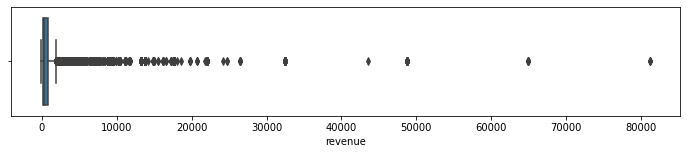

In [14]:
plt.figure(figsize=(12,2))
sns.boxplot(x=orders['revenue'])
plt.show()

In [15]:
orders['tickets_count'].describe()

count    290849.000000
mean          2.754230
std           1.170467
min           1.000000
25%           2.000000
50%           3.000000
75%           4.000000
max          57.000000
Name: tickets_count, dtype: float64

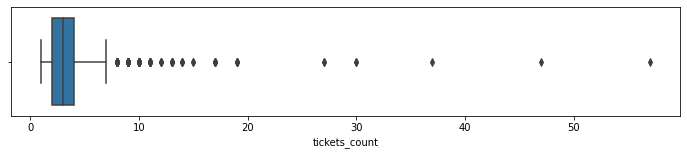

In [16]:
plt.figure(figsize=(12,2))
sns.boxplot(x=orders['tickets_count'])
plt.show()

In [17]:
rub = orders.query("currency_code=='rub'")
kzt = orders.query("currency_code=='kzt'")

rub['revenue'].describe()

count    285780.000000
mean        547.568333
std         871.524559
min         -90.760000
25%         113.827500
50%         346.100000
75%         791.700000
max       81174.540000
Name: revenue, dtype: float64

In [18]:
rub['revenue'].describe

<bound method NDFrame.describe of 0         1521.94
1          289.45
2         1258.57
3            8.49
4         1390.41
           ...   
290844     965.57
290845    1448.36
290846     178.95
290847     661.53
290848     802.25
Name: revenue, Length: 285780, dtype: float64>

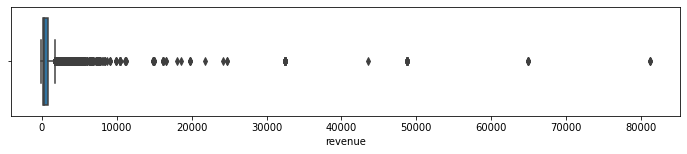

In [19]:
plt.figure(figsize=(12,2))
sns.boxplot(x=rub['revenue'])
plt.show()

In [20]:
rub_99 = rub['revenue'].quantile(0.99)
rub_99

2569.5942000000005

In [21]:
rub = rub.query('revenue <= @rub_99')

In [22]:
kzt['revenue'].describe()

count     5069.000000
mean      4995.206767
std       4916.752776
min          0.000000
25%        518.100000
50%       3698.830000
75%       7397.660000
max      26425.860000
Name: revenue, dtype: float64

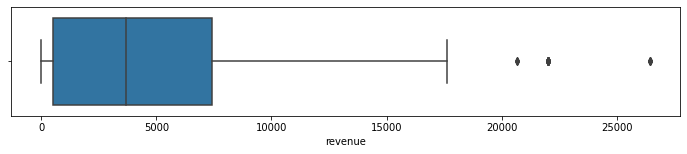

In [23]:
plt.figure(figsize=(12,2))
sns.boxplot(x=kzt['revenue'])
plt.show()

In [24]:
kzt_99 = kzt['revenue'].quantile(0.99)
kzt_99

17617.24

In [25]:
kzt = kzt.query('revenue <= @kzt_99')

In [26]:
orders = pd.concat([rub, kzt], ignore_index=True)

In [27]:
tenge.head

<bound method NDFrame.head of            data  nominal     curs  cdx
0    2024-01-10      100  19.9391  kzt
1    2024-01-11      100  19.7255  kzt
2    2024-01-12      100  19.5839  kzt
3    2024-01-13      100  19.4501  kzt
4    2024-01-14      100  19.4501  kzt
..          ...      ...      ...  ...
352  2024-12-27      100  19.2705  kzt
353  2024-12-28      100  19.5105  kzt
354  2024-12-29      100  19.4860  kzt
355  2024-12-30      100  19.4860  kzt
356  2024-12-31      100  19.4860  kzt

[357 rows x 4 columns]>

In [28]:
tenge['data']=pd.to_datetime(tenge['data'])
orders['created_dt_msk']=pd.to_datetime(orders['created_dt_msk'])

In [29]:
rates=tenge[['data','curs']]

In [30]:
orders=orders.merge(rates,left_on='created_dt_msk',right_on='data',how='left')

In [31]:
orders['revenue_rub'] = np.where(
    orders['currency_code']=='rub',
    orders['revenue'],
    orders['revenue'] * orders['curs'] / 100
)

In [32]:
orders['revenue_rub'].describe()

count    287962.000000
mean        517.864106
std         514.506310
min         -90.760000
25%         111.345000
50%         343.440000
75%         787.922500
max        3504.562319
Name: revenue_rub, dtype: float64

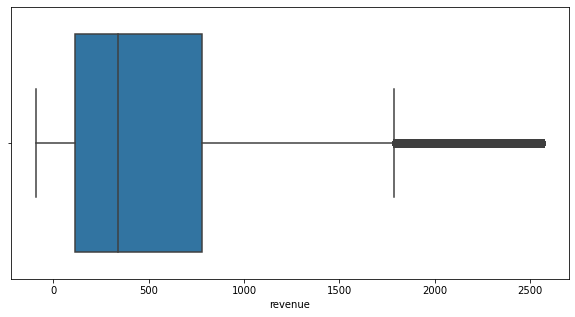

In [33]:
plt.figure(figsize=(10,5))
sns.boxplot(x=rub['revenue'])
plt.show()

Распределения revenue и tickets_count изучены с помощью описательной статистики и диаграмм размаха. Анализ выручки выполнен отдельно для заказов в рублях и тенге. Экстремальные значения revenue, превышающие 99-й процентиль в каждой валюте, исключены из дальнейшего анализа. Все значения выручки приведены к единой валюте (рублям) с использованием официального курса тенге на дату заказа, что обеспечивает корректность последующего анализа.

---

### Явные и неявные дубликаты

In [34]:
orders.duplicated().sum()

0

In [35]:
orders.duplicated(
    subset=[
        'user_id',
        'created_dt_msk',
        'event_id',
        'tickets_count',
        'revenue',
        'device_type_canonical'
    ]
).sum()

51075

In [36]:
cols = orders.columns.drop('order_id')

duplicates = (
    orders[
        orders.duplicated(
            subset=cols,
            keep=False)].sort_values(['user_id', 'created_ts_msk']))

duplicates

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev,data,curs,revenue_rub
11496,1123983,06eb7897f65b433,2024-08-13,2024-08-13 16:31:07,183706,нет,18,rub,mobile,69.82,Билеты в руки,1,997.48,0.0,2024-08-13,18.8553,69.82
11497,1123867,06eb7897f65b433,2024-08-13,2024-08-13 16:31:07,183706,нет,18,rub,mobile,69.82,Билеты в руки,1,997.48,0.0,2024-08-13,18.8553,69.82
55833,160922,2564e3703075008,2024-10-30,2024-10-30 10:04:15,589005,нет,6,rub,mobile,11.23,Лови билет!,2,280.81,0.0,2024-10-30,19.9516,11.23
55836,160893,2564e3703075008,2024-10-30,2024-10-30 10:04:15,589005,нет,6,rub,mobile,11.23,Лови билет!,2,280.81,0.0,2024-10-30,19.9516,11.23
81773,3363711,3ee7dc2e115847f,2024-06-25,2024-06-25 07:32:08,277504,нет,6,rub,mobile,59.19,Билеты в руки,3,739.85,0.0,2024-06-25,18.8012,59.19
81778,3363798,3ee7dc2e115847f,2024-06-25,2024-06-25 07:32:08,277504,нет,6,rub,mobile,59.19,Билеты в руки,3,739.85,0.0,2024-06-25,18.8012,59.19
144476,2324032,7b525118ae656af,2024-10-28,2024-10-28 08:33:04,588203,нет,0,rub,mobile,26.96,Лучшие билеты,4,674.12,0.0,2024-10-28,19.9266,26.96
144480,2323916,7b525118ae656af,2024-10-28,2024-10-28 08:33:04,588203,нет,0,rub,mobile,26.96,Лучшие билеты,4,674.12,0.0,2024-10-28,19.9266,26.96
150002,5372628,7eb4fc207ecc10f,2024-08-23,2024-08-23 14:08:19,298035,нет,6,rub,mobile,126.84,Билеты без проблем,1,3170.95,0.0,2024-08-23,19.1903,126.84
150005,5372831,7eb4fc207ecc10f,2024-08-23,2024-08-23 14:08:19,298035,нет,6,rub,mobile,126.84,Билеты без проблем,1,3170.95,0.0,2024-08-23,19.1903,126.84


Явных дубликатов не обнаружено. При проверке неявных дубликатов были использованы все признаки, кроме идентификатора заказа order_id, так как он является уникальным техническим идентификатором. Было обнаружено несколько десятков полностью совпадающих записей, отличавшихся только значением order_id. Такие записи были удалены, поскольку они, вероятнее всего, являются техническими дубликатами и могут привести к искажению результатов анализа. Оснований оставлять дубликаты нет.и

In [37]:
orders = orders.drop_duplicates(subset=cols).reset_index(drop=True)

<div class="alert alert-info"> <b>Комментарии студентаV1:</b> Привет, Марат! Исправлено</div>

### Преобразование типов данных

In [38]:
orders['created_dt_msk'] = pd.to_datetime(orders['created_dt_msk'])
orders['created_ts_msk'] = pd.to_datetime(orders['created_ts_msk'])

In [39]:
int_cols = ['order_id', 'event_id', 'age_limit', 'tickets_count']

for col in int_cols:
    orders[col] = pd.to_numeric(orders[col], downcast='integer')

In [40]:
float_cols = ['revenue', 'total', 'days_since_prev']

for col in float_cols:
    orders[col] = pd.to_numeric(orders[col], downcast='float')

In [41]:
cat_cols = [
    'cinema_circuit',
    'currency_code',
    'device_type_canonical',
    'service_name',
    'age_limit']

for col in cat_cols:
    orders[col] = orders[col].astype('category')

In [42]:
for col in ['event_id', 'city_id', 'venue_id']:
    events[col] = pd.to_numeric(events[col], downcast='integer')

In [43]:
cat_cols = [
    'event_type_description',
    'event_type_main',
    'region_name',
    'city_name']

for col in cat_cols:
    events[col] = events[col].astype('category')

In [44]:
tenge['data'] = pd.to_datetime(tenge['data'])
tenge['nominal'] = pd.to_numeric(tenge['nominal'], downcast='integer')
tenge['curs'] = pd.to_numeric(tenge['curs'], downcast='float')
tenge['cdx'] = tenge['cdx'].astype('category')

In [45]:
orders.info()
events.info()
tenge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 287932 entries, 0 to 287931
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   order_id               287932 non-null  int32         
 1   user_id                287932 non-null  object        
 2   created_dt_msk         287932 non-null  datetime64[ns]
 3   created_ts_msk         287932 non-null  datetime64[ns]
 4   event_id               287932 non-null  int32         
 5   cinema_circuit         287932 non-null  category      
 6   age_limit              287932 non-null  category      
 7   currency_code          287932 non-null  category      
 8   device_type_canonical  287932 non-null  category      
 9   revenue                287932 non-null  float32       
 10  service_name           287932 non-null  category      
 11  tickets_count          287932 non-null  int8          
 12  total                  287932 non-null  floa

Столбцы с датой были преобразованы к типу `datetime`. Для числовых признаков выполнено уменьшение размерности, категориальные признаки с небольшим числом уникальных значений переведены в тип `category`. После объеднинения таблицы заказов с данными о курсах валют и добавления вычисляемого столбца `revenue_rub` общий объем памяти увеличился, что связано с появлением новых данных, а не с изменением типов данных.

### Создание новых столбцов

In [46]:
rates = tenge.set_index('data')['curs']

orders['revenue_rub'] = np.where(
    orders['currency_code'] == 'rub',
    orders['revenue'],
    orders['revenue'] * orders['created_dt_msk'].map(rates) / 100
)

In [47]:
orders['one_ticket_revenue_rub'] = (
    orders['revenue_rub'] / orders['tickets_count']
)

orders['month'] = orders['created_dt_msk'].dt.month

season_dict = {6: 'лето', 7: 'лето', 8: 'лето', 9: 'осень', 10: 'осень', 11: 'осень'}

orders['season'] = orders['month'].map(season_dict)

In [48]:
initial_rows = 290849
final_rows = len(orders)

percent = final_rows / initial_rows * 100

print(f'Исходное количество записей: {initial_rows}')
print(f'После фильтрации: {final_rows}')
print(f'Сохранено: {percent:.2f}%')

Исходное количество записей: 290849
После фильтрации: 287932
Сохранено: 99.00%


В ходе предобработки данные о заказах были дополнены информацией о курсе казахстанского тенге, что позволило привести выручку к единой валюте - российскому рублю. На основе этого признака рассчитана выручка от продажи одного билета. Из даты оформления заказа выделен номер месяца, а также создан признак сезонности, принимающий значения «зима», «весна», «лето» и «осень». Эти преобразования подготовили данные для дальнейшего анализа. Объём данных после фильтрации по 99 перцентилю составил 287962 записей из исходных 290 849, что соответствует сохранению 99.01% наблюдений.

## Исследовательский анализ данных

### Анализ распределения заказов по сегментам и их сезонные изменения

#### Количество заказов для каждого месяца

In [49]:
orders = orders.merge(events, on='event_id', how='left')

In [50]:
orders_by_month = (
    orders.groupby('month')['order_id']
    .count()
    .reset_index(name='orders_count'))

orders_by_month

,month,orders_count
0,6,34343
1,7,40410
2,8,44572
3,9,69333
4,10,99274


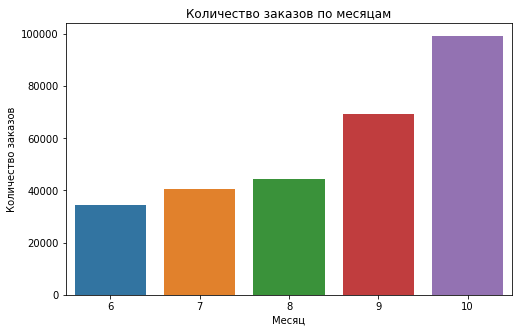

In [51]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=orders_by_month,
    x='month',
    y='orders_count')

plt.title('Количество заказов по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Количество заказов')

plt.show()

Количество заказов постепенно увеличивается с июня по октябрь, что подтверждает наличие сезонности и рост пользовательской активности осенью. Вероятно, это связано с окончанием периода отпусков, возвращением пользователей к привычному ритму жизни после летнего сезона, началом нового театрального и концертного сезона.

#### Распределение заказов билетов для осеннего и летнего периодов

In [52]:
summer = orders.query("season == 'лето'")
autumn = orders.query("season == 'осень'")

In [53]:
summer_event = (
    summer['event_type_main']
    .value_counts(normalize=True))

autumn_event = (
    autumn['event_type_main']
    .value_counts(normalize=True))

event_compare = pd.concat(
    [summer_event, autumn_event],
    axis=1)

event_compare.columns = ['summer','autumn']

event_compare = event_compare.fillna(0)

event_compare

,summer,autumn
выставки,0.020284,0.014450
другое,0.271759,0.197082
концерты,0.426139,0.371884
спорт,0.025237,0.111997
стендап,0.053279,0.041065
театр,0.201009,0.253492
ёлки,0.002292,0.010031


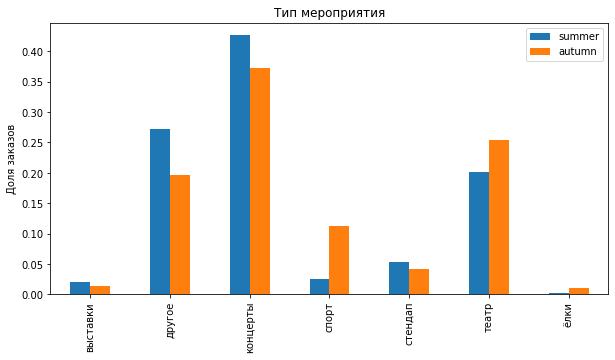

In [54]:
event_compare.plot(
    kind='bar',
    figsize=(10,5))

plt.ylabel('Доля заказов')
plt.title('Тип мероприятия')

plt.show()

Осенью увеличилась доля заказов на спортивные мероприятия, театр и ёлки в преддверии Нового года. Доля спроса на остальные мероприятия (выставки, другое, концерты, стендап) летом превышала осеннюю. Подобное изменение можно объяснить сезонным расписанием мероприятий: осенью начинается театральный сезон, проводится больше спортивных событий, а также открываются продажи новогодних представлений. Летом же пользователи чаще выбирают концерты, фестивали и другие мероприятия, характерные для сезона отпусков.

In [55]:
summer_device = summer['device_type_canonical'].value_counts(normalize=True)
autumn_device = autumn['device_type_canonical'].value_counts(normalize=True)

In [56]:
device_compare = pd.concat(
    [summer_device, autumn_device],
    axis=1)

device_compare.columns = ['summer', 'autumn']
device_compare = device_compare.fillna(0)

device_compare

,summer,autumn
mobile,0.806386,0.796551
desktop,0.193614,0.203449


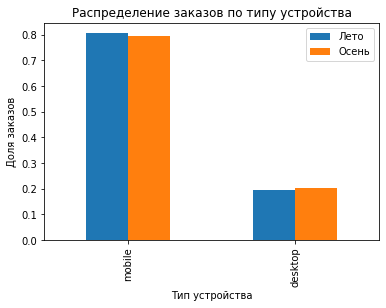

In [57]:
device_compare.plot(
    kind='bar',
    figsize=(6, 4))

plt.title('Распределение заказов по типу устройства')
plt.xlabel('Тип устройства')
plt.ylabel('Доля заказов')
plt.legend(['Лето', 'Осень'])

plt.show()

Сезон мало повлиял на распределение между мобильными устройствами и десктопом.

In [58]:
summer_age = summer['age_limit'].value_counts(normalize=True)
autumn_age = autumn['age_limit'].value_counts(normalize=True)

In [59]:
age_compare = pd.concat(
    [summer_age, autumn_age],
    axis=1)

age_compare.columns = ['summer', 'autumn']
age_compare = age_compare.fillna(0)

age_compare

,summer,autumn
0,0.179376,0.236218
6,0.181680,0.176298
12,0.205489,0.220827
16,0.283076,0.262255
18,0.150379,0.104403


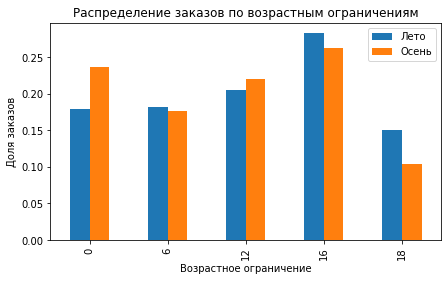

In [60]:
age_compare.plot(
    kind='bar',
    figsize=(7, 4))

plt.title('Распределение заказов по возрастным ограничениям')
plt.xlabel('Возрастное ограничение')
plt.ylabel('Доля заказов')
plt.legend(['Лето', 'Осень'])

plt.show()

Доля мероприятий категории 16+ и 18+ была более высокой летом, тогда как доля детских мероприятий в летний период была меньше. Доля мероприятий категории 0+ заметно выросла по сравнению с летом. Смена сезона не сильно повлияла на долю мероприятий категории 6+ и 12+. Вероятно, рост доли мероприятий категории 0+ связан с началом учебного года и увеличением числа семейных и детских мероприятий, а также с подготовкой к новогоднему сезону. Летом аудитория чаще посещает мероприятия, ориентированные на взрослых, что объясняет более высокую долю категорий 16+ и 18+.

#### Изменение выручки с продажи одного билета

In [61]:
ticket_price = (
    orders
    .groupby(['season','event_type_main'])['one_ticket_revenue_rub']
    .mean()
    .reset_index())

ticket_price

,season,event_type_main,one_ticket_revenue_rub
0,лето,выставки,86.416199
1,лето,другое,77.433968
2,лето,концерты,304.717072
3,лето,спорт,50.761833
4,лето,стендап,218.518112
5,лето,театр,214.126328
6,лето,ёлки,271.436188
7,осень,выставки,90.603607
8,осень,другое,76.115334
9,осень,концерты,268.084076


In [62]:
pivot = (
    ticket_price
    .pivot(
        index='event_type_main',
        columns='season',
        values='one_ticket_revenue_rub'))

pivot['change_%'] = (
    (pivot['осень'] - pivot['лето']) / pivot['лето'] * 100)

pivot

season,лето,осень,change_%
event_type_main,,,
выставки,86.416199,90.603607,4.845629
другое,77.433968,76.115334,-1.702914
концерты,304.717072,268.084076,-12.021970
спорт,50.761833,49.969734,-1.560422
стендап,218.518112,231.124969,5.769250
театр,214.126328,175.969513,-17.819769
ёлки,271.436188,229.585587,-15.418211


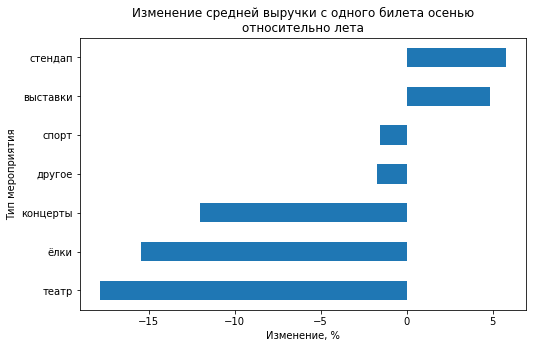

In [63]:
pivot['change_%'].sort_values().plot(
    kind='barh',
    figsize=(8, 5))

plt.title('Изменение средней выручки с одного билета осенью\nотносительно лета')
plt.xlabel('Изменение, %')
plt.ylabel('Тип мероприятия')

plt.show()

В осенний период по сравнению с летним средняя стоимость одного билета увеличилась преимущественно для стендапов и выставок, тогда как для остальных категорий изменения были отрицательными. Это может свидетельствовать как об изменении ценовой политики организаторов, так и об изменении структуры мероприятий внутри каждой категории: например, осенью могли преобладать более дорогие выставки и стендапы, тогда как в других категориях выросла доля мероприятий с более доступной стоимостью билетов.

#### Вывод
Анализ показал, что с наступлением осени пользовательская активность возрастает: количество заказов постепенно увеличивается с июня по октябрь, что подтверждает наличие сезонности. Вероятно, это связано с окончанием периода отпусков, началом нового театрального сезона и увеличением количества культурных и спортивных мероприятий.

Структура спроса также меняется. Осенью возрастает доля заказов на спортивные мероприятия, театральные постановки и новогодние представления, тогда как доля концертов, выставок, стендапов и мероприятий категории «другое» снижается. Это можно объяснить сезонными изменениями в афише мероприятий. Распределение заказов по типу устройств практически не изменилось.

По возрастным ограничениям осенью увеличивается доля мероприятий категории 0+, а доля категорий 16+ и 18+ снижается. Вероятно, это связано с ростом числа семейных мероприятий и подготовкой к новогоднему сезону.

Средняя стоимость одного билета изменилась неоднородно: заметный рост наблюдается только для стендапов и выставок, тогда как для остальных категорий она снизилась. При этом рост популярности отдельных типов мероприятий не всегда сопровождался увеличением стоимости билетов, что говорит об отсутствии прямой зависимости между спросом и средней ценой билета.

### Осенняя активность пользователей

#### Динамика изменений по дням

In [64]:
daily = (
    autumn.groupby('created_dt_msk')
    .agg(
        orders=('order_id', 'count'),
        dau=('user_id', 'nunique'),
        avg_ticket_price=('one_ticket_revenue_rub', 'mean')))

daily['orders_per_user'] = daily['orders'] / daily['dau']

In [65]:
daily_norm = daily.copy()

for col in ['orders', 'dau', 'orders_per_user', 'avg_ticket_price']:
    daily_norm[col] = daily[col] / daily[col].iloc[0]

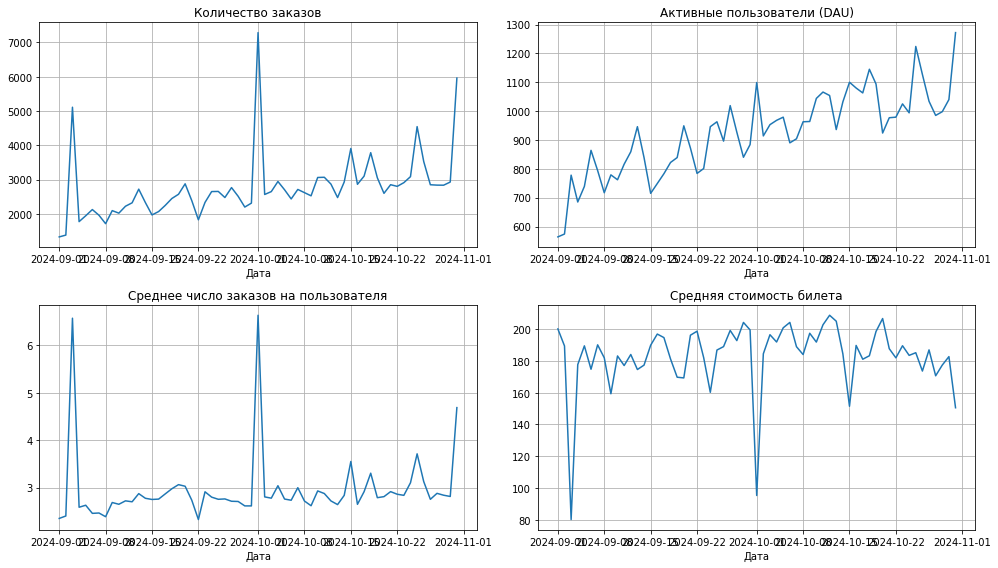

In [66]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

#заказы
axes[0, 0].plot(daily.index, daily['orders'])
axes[0, 0].set_title('Количество заказов')

#DAU
axes[0, 1].plot(daily.index, daily['dau'])
axes[0, 1].set_title('Активные пользователи (DAU)')

#заказы на пользователя
axes[1, 0].plot(daily.index, daily['orders_per_user'])
axes[1, 0].set_title('Среднее число заказов на пользователя')

#средняя стоимость билета
axes[1, 1].plot(daily.index, daily['avg_ticket_price'])
axes[1, 1].set_title('Средняя стоимость билета')

for ax in axes.flat:
    ax.set_xlabel('Дата')
    ax.grid(True)

plt.tight_layout()
plt.show()

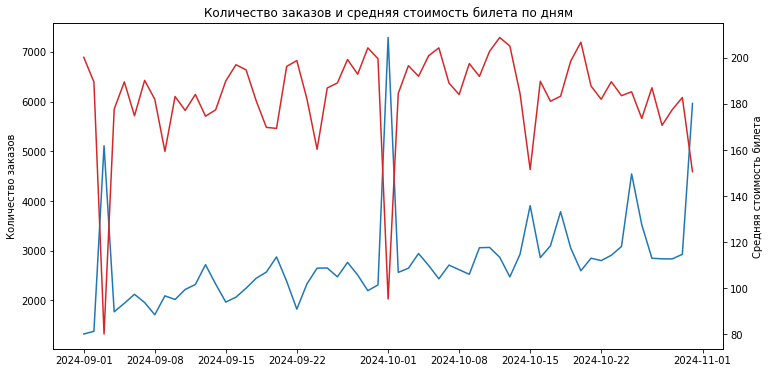

In [67]:
fig, ax1 = plt.subplots(figsize=(12,6))

ax1.plot(
    daily.index,
    daily['orders'],
    color='tab:blue',
    label='Количество заказов')

ax1.set_ylabel('Количество заказов')

ax2 = ax1.twinx()

ax2.plot(
    daily.index,
    daily['avg_ticket_price'],
    color='tab:red',
    label='Средняя стоимость билета')

ax2.set_ylabel('Средняя стоимость билета')
ax1.set_title('Количество заказов и средняя стоимость билета по дням')

plt.show()

На графике заметно, что пики количества заказов совпадают с резким снижением средней стоимости одного билета. Вероятно, в эти дни пользователи активнее приобретали билеты на более массовые и доступные мероприятия либо проводились акции и специальные предложения, что способствовало увеличению числа заказов при одновременном снижении средней стоимости билета.

#### Недельная цикличность

In [68]:
autumn = orders.query("season == 'осень'").copy()

In [69]:
autumn['weekday'] = autumn['created_dt_msk'].dt.day_name()

weekday_stats = (
    autumn.groupby('weekday')
    .agg(
        orders=('order_id', 'count'),
        dau=('user_id', 'nunique'),
        avg_ticket_price=('one_ticket_revenue_rub', 'mean')))

weekday_stats['orders_per_user'] = (
    weekday_stats['orders'] / weekday_stats['dau'])

weekday_order = {
    'Monday': 1,
    'Tuesday': 2,
    'Wednesday': 3,
    'Thursday': 4,
    'Friday': 5,
    'Saturday': 6,
    'Sunday': 7}

weekday_stats['order'] = weekday_stats.index.map(weekday_order)

weekday_stats = (
    weekday_stats
    .sort_values('order')
    .drop(columns='order'))

weekday_stats

,orders,dau,avg_ticket_price,orders_per_user
weekday,,,,
Monday,21517,4448,184.081650,4.837455
Tuesday,31480,4793,140.496796,6.567912
Wednesday,22888,4813,185.685150,4.755454
Thursday,27169,4970,177.888275,5.466600
Friday,24828,4870,185.542068,5.098152
Saturday,21336,4571,192.079956,4.667688
Sunday,19389,4394,197.921021,4.412608


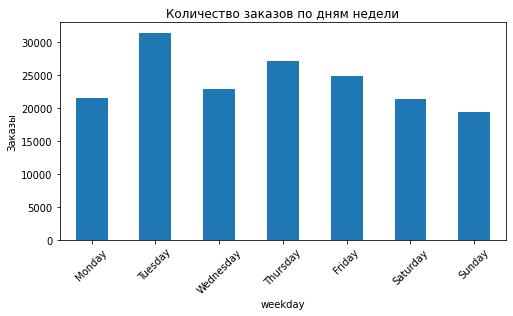

In [70]:
weekday_stats['orders'].plot(kind='bar', figsize=(8,4))
plt.title('Количество заказов по дням недели')
plt.ylabel('Заказы')
plt.xticks(rotation=45)
plt.show()

In [71]:
weekday_stats['dau']
weekday_stats['orders_per_user']
weekday_stats['avg_ticket_price']

weekday
Monday       184.081650
Tuesday      140.496796
Wednesday    185.685150
Thursday     177.888275
Friday       185.542068
Saturday     192.079956
Sunday       197.921021
Name: avg_ticket_price, dtype: float32

In [72]:
weekday_stats = weekday_stats.reset_index()

weekday_stats['day_type'] = weekday_stats['weekday'].isin(
    ['Saturday', 'Sunday']
).map({True: 'Выходной', False: 'Будний'})

In [73]:
weekend_compare = (
    weekday_stats
    .groupby('day_type')
    .mean(numeric_only=True))

weekend_compare

,orders,dau,avg_ticket_price,orders_per_user
day_type,,,,
Будний,25576.4,4778.8,174.738785,5.345114
Выходной,20362.5,4482.5,195.000488,4.540148


Анализ показал наличие недельной цикличности. В будние дни наблюдается более высокая пользовательская активность: увеличивается количество заказов, среднее количество билетов на пользователя и число активных пользователей по сравнению с выходными днями. Одновременно с этим, средняя цена билета ниже, чем в выходные. Это логично, ведь вход на мероприятия, проходящие по выходным, обычно, стоит дороже.

#### Вывод

Анализ пользовательской активности показал, что в течение осеннего периода наблюдается выраженная недельная цикличность. Наиболее высокая активность пользователей приходится на первую половину недели: в эти дни увеличиваются количество заказов, число активных пользователей и среднее количество заказов на одного пользователя. Во второй половине недели эти показатели постепенно снижаются. При этом средняя стоимость одного билета имеет обратную динамику: в периоды высокой активности пользователей она ниже, тогда как в выходные дни стоимость билетов возрастает. Это модет быть связано с более высокой стоимостью мероприятий, проводимых в выходные дни.

### Популярные события и партнёры

In [74]:
regions = (
    orders.groupby('region_name')
    .agg(
        events=('event_id', 'nunique'),
        orders=('order_id', 'count')))

In [75]:
regions['events_share'] = (
    regions['events'] / regions['events'].sum()
    *100)

regions['orders_share'] = (
    regions['orders'] / regions['orders'].sum()
    *100)

In [76]:
regions = regions.sort_values('orders', ascending=False)

regions.head(10)

,events,orders,events_share,orders_share
region_name,,,,
Каменевский регион,5935,89665,26.544121,31.166795
Североярская область,3800,43738,16.995393,15.202959
Широковская область,1232,16169,5.510085,5.620208
Медовская область,504,13892,2.254126,4.828742
Озернинский край,349,10348,1.560893,3.596877
Светополянский округ,1075,7502,4.807907,2.607632
Малиновоярский округ,165,6314,0.737958,2.194693
Солнечноземская область,522,6278,2.334630,2.182180
Речиновская область,702,6267,3.139675,2.178356


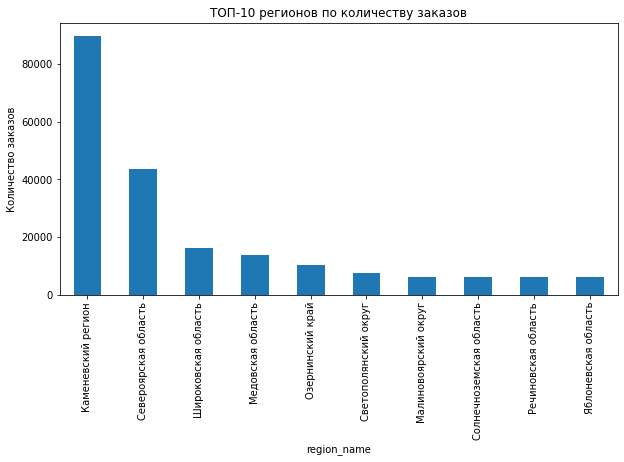

In [77]:
regions['orders'].head(10).plot(
    kind='bar',
    figsize=(10,5))

plt.title('ТОП-10 регионов по количеству заказов')
plt.ylabel('Количество заказов')

plt.show()

Наибольшее разнообразие мероприятий представлено в Каменевском районе. Этот регион имеет наибольшую часть заказов, тогда как остальные регионы имеют меньшую долю рынка.

In [78]:
partners = (
    orders.groupby('service_name')
    .agg(
        events=('event_id','nunique'),
        orders=('order_id','count'),
        revenue=('revenue_rub','sum')))

In [79]:
partners['orders_share'] = (
    partners['orders'] / partners['orders'].sum() *100)

partners['revenue_share'] = (
    partners['revenue'] / partners['revenue'].sum() *100)

partners['events_share'] = (
    partners['events'] / partners['events'].sum() *100)

In [80]:
partners = partners.sort_values(
    'revenue',
    ascending=False)

partners

,events,orders,revenue,orders_share,revenue_share,events_share
service_name,,,,,,
Билеты без проблем,4255,63022,2.425535e+07,21.887807,16.266191,17.435666
Мой билет,1302,34444,2.204261e+07,11.962547,14.782275,5.335191
Облачко,2335,26402,1.858861e+07,9.169526,12.465947,9.568104
Лови билет!,4869,40802,1.667060e+07,14.170707,11.179681,19.951647
Весь в билетах,855,16410,1.649467e+07,5.699262,11.061700,3.503524
Билеты в руки,3536,40302,1.319691e+07,13.997055,8.850146,14.489428
Край билетов,252,6109,6.405689e+06,2.121682,4.295801,1.032618
Прачечная,1026,10222,4.746810e+06,3.550144,3.183319,4.204229
Дом культуры,272,4412,4.358656e+06,1.532306,2.923014,1.114571


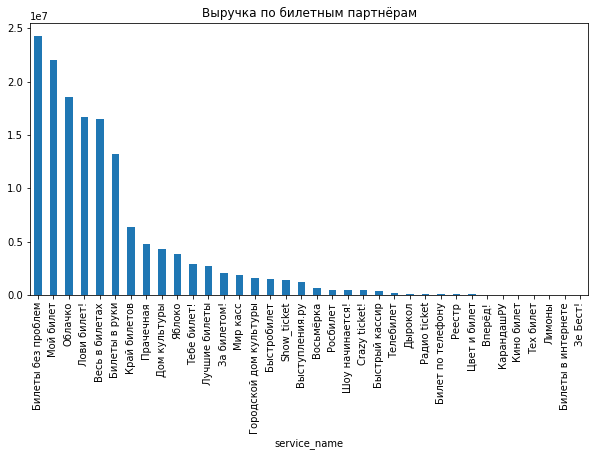

In [81]:
partners['revenue'].plot(
    kind='bar',
    figsize=(10,5))

plt.title('Выручка по билетным партнёрам')

plt.show()

Партнёры "Билеты без проблем", "Мой билет" и "Облачко" обрабатывают большую часть заказов и формируют основную долю выручки.

Распределение нельзя назвать равномерным, наблюдается высокая концентрация мероприятий, заказазов в небольшом числе регионов у ограниченного числа билетных партнёров.

## Статистический анализ данных

#### Среднее количество заказов

Нулевая гипотеза: среднее количество заказов на одного пользователя мобильных устройств не выше, чем у пользователей десктопных устройств.

Альтернативная гипотеза: среднее количество заказов на одного пользователя мобильных устройств выше, чем у пользователей десктопных устройств.

In [82]:
orders_per_user = (
    autumn.groupby(['device_type_canonical', 'user_id'])
    .agg(orders=('order_id', 'count'))
    .reset_index())

mobile = orders_per_user.query(
    "device_type_canonical == 'mobile'")['orders']

desktop = orders_per_user.query(
    "device_type_canonical == 'desktop'")['orders']

In [83]:
mobile.describe()
desktop.describe()

count    15809.000000
mean         2.169840
std         20.233616
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max       1502.000000
Name: orders, dtype: float64

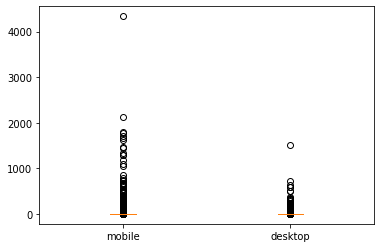

In [84]:
plt.boxplot([mobile, desktop], labels=['mobile', 'desktop'])
plt.show()

In [85]:
#проверка на пересечение
orders.groupby('user_id')['device_type_canonical'].nunique().value_counts()

1    16891
2     4956
Name: device_type_canonical, dtype: int64

In [86]:
device_count = (autumn.groupby('user_id')['device_type_canonical'].nunique())

multi_device_users = device_count[device_count > 1].index

autumn_test = autumn[~autumn['user_id'].isin(multi_device_users)]

In [87]:
orders_per_user = (
    autumn_test.groupby(['device_type_canonical', 'user_id'])
    .agg(orders=('order_id', 'count'))
    .reset_index())

metric_mobile = orders_per_user.loc[
    orders_per_user['device_type_canonical'] == 'mobile',
    'orders']

metric_desktop = orders_per_user.loc[
    orders_per_user['device_type_canonical'] == 'desktop',
    'orders']

In [88]:
orders_per_user.groupby('device_type_canonical')['orders'].describe()

,count,mean,std,min,25%,50%,75%,max
device_type_canonical,,,,,,,,
desktop,12559.0,0.254558,1.282739,0.0,0.0,0.0,0.0,56.0
mobile,12559.0,2.490007,3.941911,0.0,1.0,1.0,3.0,123.0


Распределения показателей имеют выраженную асимметрию, содержат большое число одинаковых значений (около 70% наблюдений имеют значение 0 для days_since_prev) и выбросы. Поэтому для проверки гипотез выбран непараметрический критерий Манна–Уитни.

In [89]:
device_count = (
    autumn.groupby('user_id')['device_type_canonical']
    .nunique())

multi_device_users = device_count[device_count > 1].index

autumn_test = autumn[
    ~autumn['user_id'].isin(multi_device_users)]

In [90]:
alpha = 0.05

stat_mw, p_value_mw = mannwhitneyu(
    metric_mobile,
    metric_desktop,
    alternative='greater')

if p_value_mw > alpha:
    print(f'p-value = {p_value_mw:.3e} > {alpha}')
    print('Нет оснований отвергнуть нулевую гипотезу.')
else:
    print(f'p-value = {p_value_mw:.3e} < {alpha}')
    print('Нулевая гипотеза отвергается.')

p-value = 0.000e+00 < 0.05
Нулевая гипотеза отвергается.


#### Среднее время между заказами

**Нулевая гипотеза:** время между заказами пользователей мобильных устройств не выше, чем у пользователей стационарных устройств.

**Альтернативная гипотеза:** время между заказами пользователей мобильных устройств выше, чем у пользователей стационарных устройств.

In [91]:
days_between = autumn_test.dropna(subset=['days_since_prev'])

metric_mobile = days_between.loc[
    days_between['device_type_canonical'] == 'mobile',
    'days_since_prev']

metric_desktop = days_between.loc[
    days_between['device_type_canonical'] == 'desktop',
    'days_since_prev']

print(metric_mobile.describe())
print(metric_desktop.describe())

days_between.groupby('device_type_canonical')['days_since_prev'].describe()

count    24591.000000
mean        13.789069
std         25.714392
min          0.000000
25%          0.000000
50%          1.000000
75%         15.000000
max        148.000000
Name: days_since_prev, dtype: float64
count    2078.000000
mean       18.061598
std        32.669453
min         0.000000
25%         0.000000
50%         0.000000
75%        22.000000
max       146.000000
Name: days_since_prev, dtype: float64


,count,mean,std,min,25%,50%,75%,max
device_type_canonical,,,,,,,,
desktop,2078.0,18.061598,32.669453,0.0,0.0,0.0,22.0,146.0
mobile,24591.0,13.789069,25.714392,0.0,0.0,1.0,15.0,148.0


In [92]:
alpha = 0.05

stat_mw, p_value_mw = mannwhitneyu(
    metric_mobile,
    metric_desktop,
    alternative='greater')

if p_value_mw > alpha:
    print(f'p-value = {p_value_mw:.3e} > {alpha}')
    print('Нет оснований отвергнуть нулевую гипотезу.')
else:
    print(f'p-value = {p_value_mw:.3e} < {alpha}')
    print('Нулевая гипотеза отвергается.')

p-value = 5.148e-08 < 0.05
Нулевая гипотеза отвергается.


## Общий вывод и рекомендации

#### Информация о данных
В ходе проекта были проанализированы данные о бронировании билетов на сервисе Яндекс Афиша за период с июня по октябрь 2024 года. Предварительно была проведена предобработка данных: обработаны пропуски и дубликаты, проверены типы данных, выручка приведена к единой валюте (российским рублям), исключены выбросы по 99-му процентилю, а также созданы дополнительные признаки для последующего анализа.

#### Основные результаты анализа
Исследовательский анализ показал наличие выраженной сезонности: количество заказов постепенно увеличивалось с июня по октябрь. Осенью выросла доля заказов на спортивные мероприятия, театральные постановки и новогодние мероприятия, тогда как доля концертов, выставок, стендапов и прочих событий несколько снизилась. Существенных изменений в распределении заказов между мобильными и стационарными устройствами выявлено не было. Также осенью увеличилась доля мероприятий с возрастным ограничением 0+, тогда как доля категорий 16+ и 18+ снизилась.

Анализ средней стоимости одного билета показал, что осенью стоимость выросла преимущественно для стендапов и выставок, тогда как для большинства остальных типов мероприятий наблюдалось небольшое снижение средней стоимости билета. Исследование пользовательской активности подтвердило наличие как сезонной, так и недельной цикличности: в будние дни пользователи оформляют больше заказов и проявляют более высокую активность, тогда как в выходные средняя стоимость билета выше.

Анализ распределения мероприятий по регионам и билетным партнёрам показал, что рынок неоднороден: отдельные регионы и партнёры являются явными лидерами как по количеству мероприятий и заказов, так и по объёму выручки, в то время как большинство остальных участников имеют значительно меньшие показатели.

#### Результаты проверки гипотез
Для проверки различий между пользователями мобильных и стационарных устройств были сформулированы и проверены две статистические гипотезы с использованием критерия Манна–Уитни. Результаты показали статистически значимые различия между группами. Пользователи мобильных устройств совершают больше заказов на одного пользователя по сравнению с пользователями стационарных устройств. Также статистически значимые различия были выявлены для времени между заказами: согласно результатам теста, этот показатель оказался выше у пользователей мобильных устройств. При интерпретации второго результата следует учитывать, что увеличение времени между заказами не всегда соответствует представлению о более высокой пользовательской активности, поэтому данный вывод требует осторожной интерпретации.

#### Рекомендации
В первую очередь рекомендуется учитывать выраженную сезонность спроса при планировании маркетинговых кампаний и взаимодействии с организаторами мероприятий, уделяя особое внимание осеннему периоду. Также стоит развивать направления, демонстрирующие рост интереса пользователей, прежде всего спортивные мероприятия и театральные постановки. Дополнительно рекомендуется проанализировать причины изменения стоимости билетов по различным категориям мероприятий и провести более детальное исследование поведения пользователей мобильных устройств, чтобы уточнить причины выявленных различий в частоте оформления заказов и интервалах между покупками.